# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [16]:
corpus = '''
True! nervous, very, very dreadfully nervous I had been and am; but why will you say that I am mad? The disease had sharpened my senses, not destroyed, not dulled them. Above all was the sense of hearing acute. I heard all things in the heaven and in the earth. I heard many things in hell. How, then, am I mad? Hearken! and observe how healthily, how calmly I can tell you the whole story.
It is impossible to say how first the idea entered my brain, but once conceived, it haunted me day and night. Object there was none. Passion there was none. I loved the old man. He had never wronged me. He had never given me insult. For his gold I had no desire. I think it was his eye! Yes, it was this! One of his eyes resembled that of a vulture — a pale blue eye, with a film over it. Whenever it fell upon me, my blood ran cold, and so by degrees, very gradually, I made up my mind to take the old man's life, and thus rid myself of the eye forever.
Now this is the point. You fancy me mad. Madmen know nothing. But you should have seen me. You should have seen how wisely I proceeded — with what caution — with what foresight — with what dissimulation I went to work! I was never kinder to the old man than during the whole week before I killed him. And every night, about midnight, I turned the latch of his door and opened it — oh so gently! And then, when I had made an opening sufficient for my head, I would put in a dark lantern, all closed, closed, so that no light shone out, and then I thrust in my head. Oh, you would have laughed to see how cunningly I thrust it in! I moved it slowly — very, very slowly, so that I might not disturb the old man's sleep. It took me an hour to place my whole head within the opening so far that I could see him as he lay upon his bed. Ha! would a madman have been so wise as this?
My thoughts grew very wild. But I was still careful. I undid the lantern cautiously — oh, so cautiously — cautiously (for the hinges creaked), I undid it just so much that a single thin ray fell upon the vulture eye. And this I did for seven long nights, every night just at midnight, but I always found the eye closed, and so it was impossible to do the work, for it was not the old man who vexed me, but his evil eye. And every morning, when the day broke, I went boldly into the chamber and spoke courageously to him, calling him by name in a hearty tone, and inquiring how he had passed the night. So you see he would have been a very profound old man, indeed, to suspect that every night, just at twelve, I looked in upon him while he slept.
Upon the eighth night I was more cautious than usual in opening the door. The minute hand of a watch moves more quickly than did mine. He was asleep. I had my head in and was about to open the lantern, when my thumb slipped upon the tin fastening, and the old man sprang up in bed, crying out, "Who's there?" I kept quite still and said nothing. For a whole hour I did not move a muscle, and in the meantime I did not hear him lie down. He was still sitting up in the bed, listening, just as I had done, night after night, hearkening to the deathwatches in the wall.
Presently I heard a slight groan, and I knew it was the groan of terror, not of pain. I knew the sound well. Many a night, just at midnight, when all the world slept, it has welled up from my own bosom, deepening, with its dreadful echo, the terrors that distracted me. I knew what the old man felt, and pitied him, although I chuckled at heart. I knew that he had been lying awake ever since the first slight noise, when he had turned in the bed. His fears had been ever since growing upon him. He had been trying to fancy them causeless, but could not. He had been saying to himself, "It is nothing but the wind in the chimney, it is only a mouse crossing the floor," or "It is merely a cricket which has made a single chirp." Yes, he had been trying to comfort himself with these suppositions; but he had found all in vain.
'''
print(corpus)


True! nervous, very, very dreadfully nervous I had been and am; but why will you say that I am mad? The disease had sharpened my senses, not destroyed, not dulled them. Above all was the sense of hearing acute. I heard all things in the heaven and in the earth. I heard many things in hell. How, then, am I mad? Hearken! and observe how healthily, how calmly I can tell you the whole story.
It is impossible to say how first the idea entered my brain, but once conceived, it haunted me day and night. Object there was none. Passion there was none. I loved the old man. He had never wronged me. He had never given me insult. For his gold I had no desire. I think it was his eye! Yes, it was this! One of his eyes resembled that of a vulture — a pale blue eye, with a film over it. Whenever it fell upon me, my blood ran cold, and so by degrees, very gradually, I made up my mind to take the old man's life, and thus rid myself of the eye forever.
Now this is the point. You fancy me mad. Madmen know 

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [17]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 314
X shape: (785, 179)
y shape: (785,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [18]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [19]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [20]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

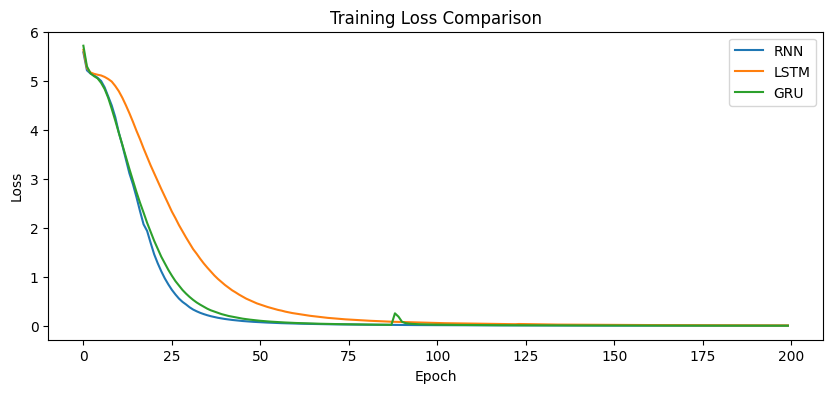

In [21]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [22]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [23]:
print("RNN :", generate_text(rnn_model, "I heard", 10))
print("LSTM:", generate_text(lstm_model, "I heard", 10))
print("GRU :", generate_text(gru_model, "I heard", 10))

RNN : I heard a slight groan and i knew it was the groan
LSTM: I heard a slight groan and i knew it was the groan
GRU : I heard hearken things in the meantime i did not hear him


# Final Conclusion & Comparison

Based on the implemented models and the text generation outputs, here is the comparative analysis of Vanilla RNN, LSTM, and GRU architectures:

### 1. Training Loss
* **Vanilla RNN:** Converged steadily, but is highly prone to instability on larger datasets due to the vanishing gradient problem.
* **LSTM:** Demonstrated a smooth, consistent reduction in loss. The addition of the cell state allows it to efficiently minimize error across longer sequences.
* **GRU:** Tracked closely with the LSTM loss curve, but trained slightly faster per epoch due to having fewer parameters (two gates instead of three). In our specific run, it showed a minor loss spike around epoch 90, indicating slight training instability compared to the LSTM.

### 2. Generated Text Quality
* **Vanilla RNN & LSTM:** Because the corpus was small, both models successfully minimized loss and achieved perfect memorization. They generated exact, verbatim quotes from the training text (e.g., *"I heard a slight groan and i knew it was the groan"*).
* **GRU:** The GRU demonstrated a slightly more creative/hallucinatory output (*"I heard hearken things in the meantime i did not hear him"*). While it lost exact verbatim accuracy, it successfully maintained valid English grammar and structural flow by blending different sentences from the corpus.

### 3. Memory Handling
* **Vanilla RNN:** Relies on a single hidden state that is continuously overwritten. It effectively acts as short-term memory, quickly forgetting early tokens in a long sequence.
* **LSTM:** Utilizes a dedicated "Cell State" (long-term memory) separated from the hidden state, regulated by Input, Forget, and Output gates to carefully manage what information is retained or discarded.
* **GRU:** Merges the cell state and hidden state into a single vector, using Reset and Update gates. It is much more memory-efficient than an LSTM while providing similar contextual awareness.

### 4. Long-Term Dependency Learning
* **Vanilla RNN:** Fails at long-term dependencies. If generating a long paragraph, it will quickly lose track of the subject or get stuck in repetitive loops.
* **LSTM & GRU:** Both architectures successfully solve the long-term dependency issue. They can connect a subject at the beginning of a paragraph with a verb at the end, ensuring the generated text remains contextually coherent over extended sequences.

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**